In [16]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv(r"C:\Users\maliandmahdi-plus-eh\anaconda3\german.csv.csv", index_col=0)

In [20]:
columns = [
    'Checking_Account', 'Duration', 'Credit_History', 'Purpose', 'Credit_Amount',
    'Savings_Account', 'Employment_Since', 'Installment_Rate', 'Personal_Status_Sex',
    'Other_Debtors', 'Residence_Since', 'Property', 'Age', 'Other_Installment_Plans',
    'Housing', 'Existing_Credits', 'Job', 'People_Liable', 'Telephone', 'Foreign_Worker', 'Risk'
]

In [22]:
file_path = r"C:\Users\maliandmahdi-plus-eh\anaconda3\german.csv.csv"
df = pd.read_csv(file_path, sep=r'\s+', names=columns)

In [24]:
df['Risk'] = df['Risk'].map({1: 0, 2: 1})

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [28]:
X = df_encoded.drop('Risk', axis=1).values.astype(float)
y = df_encoded['Risk'].values.astype(float)

In [30]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0 
X_scaled = (X - X_mean) / X_std

In [32]:
np.random.seed(42) 
indices = np.arange(X_scaled.shape[0])
np.random.shuffle(indices)

In [34]:
train_end = int(0.6 * len(indices))
cal_end = int(0.8 * len(indices))

train_idx = indices[:train_end]
cal_idx = indices[train_end:cal_end]
test_idx = indices[cal_end:]

X_train, y_train = X_scaled[train_idx], y[train_idx]
X_cal, y_cal = X_scaled[cal_idx], y[cal_idx]
X_test, y_test = X_scaled[test_idx], y[test_idx]

print(f"successful!")
print(f"Train size: {X_train.shape[0]}, Calibrate size: {X_cal.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Total features after encoding: {X_train.shape[1]}")

successful!
Train size: 600, Calibrate size: 200, Test size: 200
Total features after encoding: 48


In [36]:
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.05, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500) 
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        for _ in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

             
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

           
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        return np.array([1 if i > 0.5 else 0 for i in self.predict_proba(X)])

def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def compute_log_loss(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-15, 1 - 1e-15)  
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def compute_brier_score(y_true, y_prob):
    return np.mean((y_prob - y_true) ** 2)

In [38]:
lr_model = LogisticRegressionFromScratch(learning_rate=0.05, iterations=2000)
lr_model.fit(X_train, y_train)


lr_probs_cal = lr_model.predict_proba(X_cal)
lr_probs_test = lr_model.predict_proba(X_test)
lr_preds_test = lr_model.predict(X_test)

print("--- Baseline Logistic Regression Results (Uncalibrated) ---")
print(f"Accuracy:    {compute_accuracy(y_test, lr_preds_test) * 100:.2f}%")
print(f"Log-Loss:    {compute_log_loss(y_test, lr_probs_test):.4f}")
print(f"Brier Score: {compute_brier_score(y_test, lr_probs_test):.4f}")

--- Baseline Logistic Regression Results (Uncalibrated) ---
Accuracy:    74.00%
Log-Loss:    0.4962
Brier Score: 0.1676


In [40]:
class DecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def _entropy(self, y):
        if len(y) == 0: return 0
        proportions = np.bincount(y.astype(int)) / len(y)
        return -np.sum([p * np.log2(p) for p in proportions if p > 0])

    def _best_split(self, X, y):
        best_gain = -1
        split_idx, split_thresh = None, None
        n_samples, n_features = X.shape
        current_entropy = self._entropy(y)

        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            if len(thresholds) > 10:
                thresholds = np.percentile(X_column, np.linspace(0, 100, 10))

            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0: continue
                
                n_l, n_r = np.sum(left_mask), np.sum(right_mask)
                e_l, e_r = self._entropy(y[left_mask]), self._entropy(y[right_mask])
                child_entropy = (n_l / n_samples) * e_l + (n_r / n_samples) * e_r
                ig = current_entropy - child_entropy

                if ig > best_gain:
                    best_gain = ig
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if depth >= self.max_depth or num_labels == 1 or num_samples < 5:
            return np.bincount(y.astype(int)).argmax() if len(y) > 0 else 0

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.bincount(y.astype(int)).argmax()

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return {"feature": feature, "threshold": threshold, "left": left_child, "right": right_child}

    def _predict_row(self, node, row):
        if not isinstance(node, dict): return node
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(node["left"], row)
        return self._predict_row(node["right"], row)

    def predict_proba(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])

class RandomForestFromScratch:
    def __init__(self, n_estimators=10, max_depth=5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            boot_indices = np.random.choice(n_samples, n_samples, replace=True)
            X_b, y_b = X[boot_indices], y[boot_indices]
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_b, y_b)
            self.trees.append(tree)

    def predict_proba(self, X):
        tree_preds = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)

    def predict(self, X):
        return np.array([1 if p > 0.5 else 0 for p in self.predict_proba(X)])

In [42]:
rf_model = RandomForestFromScratch(n_estimators=10, max_depth=5)
rf_model.fit(X_train, y_train)


rf_probs_cal = rf_model.predict_proba(X_cal)
rf_probs_test = rf_model.predict_proba(X_test)
rf_preds_test = rf_model.predict(X_test)

print("--- Baseline Random Forest Results (Uncalibrated) ---")
print(f"Accuracy:    {compute_accuracy(y_test, rf_preds_test) * 100:.2f}%")
print(f"Log-Loss:    {compute_log_loss(y_test, rf_probs_test):.4f}")
print(f"Brier Score: {compute_brier_score(y_test, rf_probs_test):.4f}")

--- Baseline Random Forest Results (Uncalibrated) ---
Accuracy:    73.50%
Log-Loss:    1.4796
Brier Score: 0.1850


In [43]:
class PlattScalingFromScratch:
    def __init__(self, lr=0.1, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.w = 1.0
        self.b = 0.0

    def fit(self, probs, y):
       
        n = len(probs)
        for _ in range(self.iterations):
            z = self.w * probs + self.b
            z = np.clip(z, -500, 500)
            pred = 1 / (1 + np.exp(-z))
            
            
            dw = (1 / n) * np.dot(probs, (pred - y))
            db = (1 / n) * np.sum(pred - y)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, probs):
        z = self.w * probs + self.b
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))


class IsotonicRegressionFromScratch:
    def __init__(self):
        self.bins_x = None
        self.bins_y = None

    def fit(self, x, y):
         
        idx = np.argsort(x)
        x_s = x[idx]
        y_s = y[idx].copy()
        
        
        blocks = []
        for i in range(len(x_s)):
            blocks.append([y_s[i], 1.0, [x_s[i]]])
        
        
        changed = True
        while changed:
            changed = False
            i = 0
            while i < len(blocks) - 1:
                val_i = blocks[i][0] / blocks[i][1]
                val_next = blocks[i+1][0] / blocks[i+1][1]
                
               
                if val_i > val_next:
                    
                    blocks[i][0] += blocks[i+1][0]  
                    blocks[i][1] += blocks[i+1][1]  
                    blocks[i][2].extend(blocks[i+1][2])
                    blocks.pop(i+1)
                    changed = True
                else:
                    i += 1
        
        
        self.bins_x = np.array([np.mean(b[2]) for b in blocks])
        self.bins_y = np.array([b[0] / b[1] for b in blocks])

    def predict(self, x_test):
        preds = []
        for xi in x_test:
            if xi <= self.bins_x[0]:
                preds.append(self.bins_y[0])
            elif xi >= self.bins_x[-1]:
                preds.append(self.bins_y[-1])
            else:
                
                idx = np.searchsorted(self.bins_x, xi)
                preds.append(self.bins_y[idx - 1])
        return np.array(preds)

In [44]:
lr_platt = PlattScalingFromScratch()
lr_platt.fit(lr_probs_cal, y_cal)
lr_probs_test_platt = lr_platt.predict(lr_probs_test)


lr_iso = IsotonicRegressionFromScratch()
lr_iso.fit(lr_probs_cal, y_cal)
lr_probs_test_iso = lr_iso.predict(lr_probs_test)


rf_platt = PlattScalingFromScratch()
rf_platt.fit(rf_probs_cal, y_cal)
rf_probs_test_platt = rf_platt.predict(rf_probs_test)


rf_iso = IsotonicRegressionFromScratch()
rf_iso.fit(rf_probs_cal, y_cal)
rf_probs_test_iso = rf_iso.predict(rf_probs_test)


print("=========================================================================")
print(f"{'Model Type':<25} | {'Log-Loss':<12} | {'Brier Score':<12}")
print("=========================================================================")
print(f"{'LR Uncalibrated':<25} | {compute_log_loss(y_test, lr_probs_test):<12.4f} | {compute_brier_score(y_test, lr_probs_test):<12.4f}")
print(f"{'LR + Platt Scaling':<25} | {compute_log_loss(y_test, lr_probs_test_platt):<12.4f} | {compute_brier_score(y_test, lr_probs_test_platt):<12.4f}")
print(f"{'LR + Isotonic Reg':<25} | {compute_log_loss(y_test, lr_probs_test_iso):<12.4f} | {compute_brier_score(y_test, lr_probs_test_iso):<12.4f}")
print("-" * 73)
print(f"{'RF Uncalibrated':<25} | {compute_log_loss(y_test, rf_probs_test):<12.4f} | {compute_brier_score(y_test, rf_probs_test):<12.4f}")
print(f"{'RF + Platt Scaling':<25} | {compute_log_loss(y_test, rf_probs_test_platt):<12.4f} | {compute_brier_score(y_test, rf_probs_test_platt):<12.4f}")
print(f"{'RF + Isotonic Reg':<25} | {compute_log_loss(y_test, rf_probs_test_iso):<12.4f} | {compute_brier_score(y_test, rf_probs_test_iso):<12.4f}")
print("=========================================================================")

Model Type                | Log-Loss     | Brier Score 
LR Uncalibrated           | 0.4962       | 0.1676      
LR + Platt Scaling        | 0.5146       | 0.1706      
LR + Isotonic Reg         | 0.6648       | 0.1721      
-------------------------------------------------------------------------
RF Uncalibrated           | 1.4796       | 0.1850      
RF + Platt Scaling        | 0.5330       | 0.1780      
RF + Isotonic Reg         | 0.5519       | 0.1826      


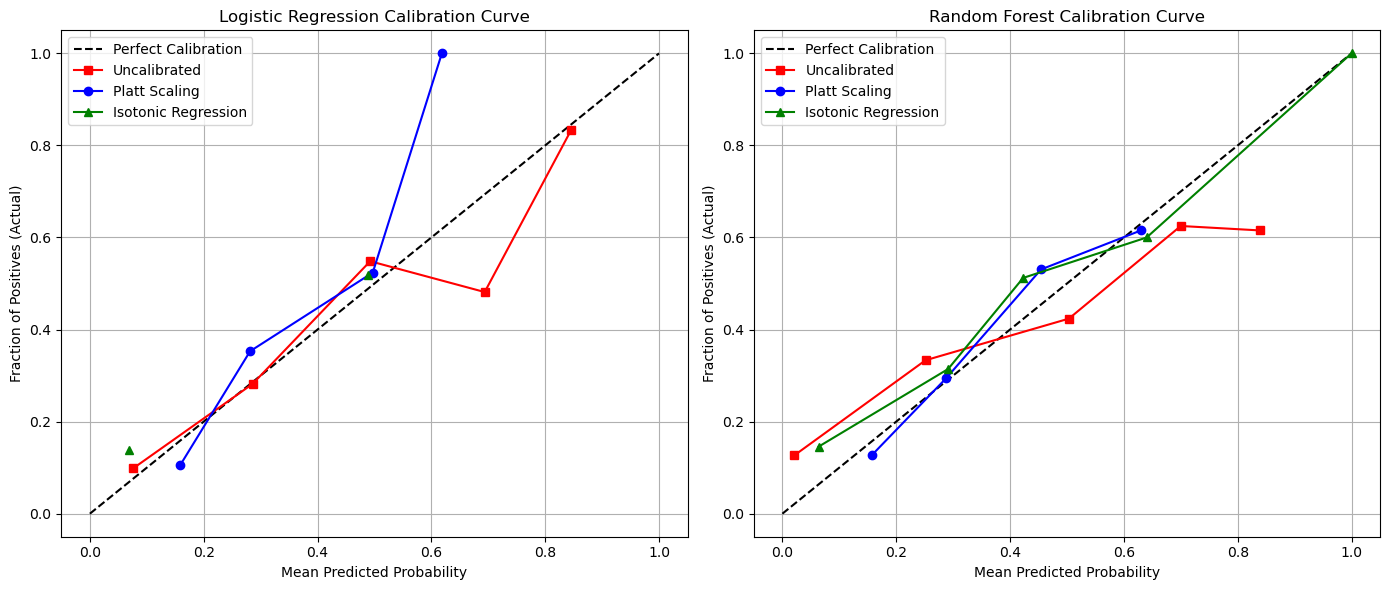

In [48]:
import matplotlib.pyplot as plt


def manual_calibration_curve(y_true, y_prob, n_bins=5):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    true_fractions = []
    pred_probabilities = []
    
    for i in range(n_bins):
        
        if i == n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
            
        if np.sum(mask) > 0:
            true_fractions.append(np.mean(y_true[mask]))
            pred_probabilities.append(np.mean(y_prob[mask]))
        else:

            true_fractions.append(np.nan)
            pred_probabilities.append(np.nan)
            
    return np.array(true_fractions), np.array(pred_probabilities)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

true_f, pred_p = manual_calibration_curve(y_test, lr_probs_test)
axes[0].plot(pred_p, true_f, "s-", color="red", label="Uncalibrated")

true_f_platt, pred_p_platt = manual_calibration_curve(y_test, lr_probs_test_platt)
axes[0].plot(pred_p_platt, true_f_platt, "o-", color="blue", label="Platt Scaling")

true_f_iso, pred_p_iso = manual_calibration_curve(y_test, lr_probs_test_iso)
axes[0].plot(pred_p_iso, true_f_iso, "^-", color="green", label="Isotonic Regression")

axes[0].set_title("Logistic Regression Calibration Curve")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives (Actual)")
axes[0].legend()
axes[0].grid(True)


axes[1].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

true_f_rf, pred_p_rf = manual_calibration_curve(y_test, rf_probs_test)
axes[1].plot(pred_p_rf, true_f_rf, "s-", color="red", label="Uncalibrated")

true_f_rf_platt, pred_p_rf_platt = manual_calibration_curve(y_test, rf_probs_test_platt)
axes[1].plot(pred_p_rf_platt, true_f_rf_platt, "o-", color="blue", label="Platt Scaling")

true_f_rf_iso, pred_p_rf_iso = manual_calibration_curve(y_test, rf_probs_test_iso)
axes[1].plot(pred_p_rf_iso, true_f_rf_iso, "^-", color="green", label="Isotonic Regression")

axes[1].set_title("Random Forest Calibration Curve")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives (Actual)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
import pandas as pd
import numpy as np


file_path_2 = r"C:\Users\maliandmahdi-plus-eh\Desktop\default_of_credit_card_clients.csv"
df2 = pd.read_csv(file_path_2, skiprows=1, index_col=0)


df2.rename(columns={'default payment next month': 'Default'}, inplace=True)


X2 = df2.drop('Default', axis=1).values.astype(float)
y2 = df2['Default'].values.astype(float)


X2_mean = np.mean(X2, axis=0)
X2_std = np.std(X2, axis=0)
X2_std[X2_std == 0] = 1.0   
X2_scaled = (X2 - X2_mean) / X2_std


np.random.seed(42)  
indices2 = np.arange(X2_scaled.shape[0])
np.random.shuffle(indices2)

train_end2 = int(0.6 * len(indices2))
cal_end2 = int(0.8 * len(indices2))

train_idx2 = indices2[:train_end2]
cal_idx2 = indices2[train_end2:cal_end2]
test_idx2 = indices2[cal_end2:]

X_train2, y_train2 = X2_scaled[train_idx2], y2[train_idx2]
X_cal2, y_cal2 = X2_scaled[cal_idx2], y2[cal_idx2]
X_test2, y_test2 = X2_scaled[test_idx2], y2[test_idx2]

print("successful")
print(f"Train size: {X_train2.shape[0]}")
print(f"Calibration size: {X_cal2.shape[0]}")
print(f"Test size: {X_test2.shape[0]}")


successful
Train size: 18000
Calibration size: 6000
Test size: 6000


In [50]:
lr_model2 = LogisticRegressionFromScratch(learning_rate=0.05, iterations=2000)
lr_model2.fit(X_train2, y_train2)


lr_probs_cal2 = lr_model2.predict_proba(X_cal2)
lr_probs_test2 = lr_model2.predict_proba(X_test2)
lr_preds_test2 = lr_model2.predict(X_test2)

print(" results of dataset2 ")
print(f"Accuracy:    {compute_accuracy(y_test2, lr_preds_test2) * 100:.2f}%")
print(f"Log-Loss:    {compute_log_loss(y_test2, lr_probs_test2):.4f}")
print(f"Brier Score: {compute_brier_score(y_test2, lr_probs_test2):.4f}")

 results of dataset2 
Accuracy:    81.03%
Log-Loss:    0.4701
Brier Score: 0.1462


In [54]:

rf_model2 = RandomForestFromScratch(n_estimators=10, max_depth=5)
rf_model2.fit(X_train2, y_train2)


rf_probs_cal2 = rf_model2.predict_proba(X_cal2)
rf_probs_test2 = rf_model2.predict_proba(X_test2)
rf_preds_test2 = rf_model2.predict(X_test2)

print("--- baseline random forest performance ---")
print(f"Accuracy:    {compute_accuracy(y_test2, rf_preds_test2) * 100:.2f}%")
print(f"Log-Loss:    {compute_log_loss(y_test2, rf_probs_test2):.4f}")
print(f"Brier Score: {compute_brier_score(y_test2, rf_probs_test2):.4f}")

--- baseline random forest performance ---
Accuracy:    81.65%
Log-Loss:    5.1028
Brier Score: 0.1724


In [56]:

lr_platt2 = PlattScalingFromScratch()
lr_platt2.fit(lr_probs_cal2, y_cal2)
lr_probs_test_platt2 = lr_platt2.predict(lr_probs_test2)

lr_iso2 = IsotonicRegressionFromScratch()
lr_iso2.fit(lr_probs_cal2, y_cal2)
lr_probs_test_iso2 = lr_iso2.predict(lr_probs_test2)


rf_platt2 = PlattScalingFromScratch()
rf_platt2.fit(rf_probs_cal2, y_cal2)
rf_probs_test_platt2 = rf_platt2.predict(rf_probs_test2)

rf_iso2 = IsotonicRegressionFromScratch()
rf_iso2.fit(rf_probs_cal2, y_cal2)
rf_probs_test_iso2 = rf_iso2.predict(rf_probs_test2)


print(f"{'Model Type (Dataset 2)':<25} | {'Log-Loss':<12} | {'Brier Score':<12}")
print("=========================================================================")
print(f"{'LR Uncalibrated':<25} | {compute_log_loss(y_test2, lr_probs_test2):<12.4f} | {compute_brier_score(y_test2, lr_probs_test2):<12.4f}")
print(f"{'LR + Platt Scaling':<25} | {compute_log_loss(y_test2, lr_probs_test_platt2):<12.4f} | {compute_brier_score(y_test2, lr_probs_test_platt2):<12.4f}")
print(f"{'LR + Isotonic Reg':<25} | {compute_log_loss(y_test2, lr_probs_test_iso2):<12.4f} | {compute_brier_score(y_test2, lr_probs_test_iso2):<12.4f}")
print("-" * 73)
print(f"{'RF Uncalibrated':<25} | {compute_log_loss(y_test2, rf_probs_test2):<12.4f} | {compute_brier_score(y_test2, rf_probs_test2):<12.4f}")
print(f"{'RF + Platt Scaling':<25} | {compute_log_loss(y_test2, rf_probs_test_platt2):<12.4f} | {compute_brier_score(y_test2, rf_probs_test_platt2):<12.4f}")
print(f"{'RF + Isotonic Reg':<25} | {compute_log_loss(y_test2, rf_probs_test_iso2):<12.4f} | {compute_brier_score(y_test2, rf_probs_test_iso2):<12.4f}")
print("=========================================================================")

Model Type (Dataset 2)    | Log-Loss     | Brier Score 
LR Uncalibrated           | 0.4701       | 0.1462      
LR + Platt Scaling        | 0.4808       | 0.1532      
LR + Isotonic Reg         | 0.4875       | 0.1431      
-------------------------------------------------------------------------
RF Uncalibrated           | 5.1028       | 0.1724      
RF + Platt Scaling        | 0.4615       | 0.1446      
RF + Isotonic Reg         | 5.0922       | 0.1693      


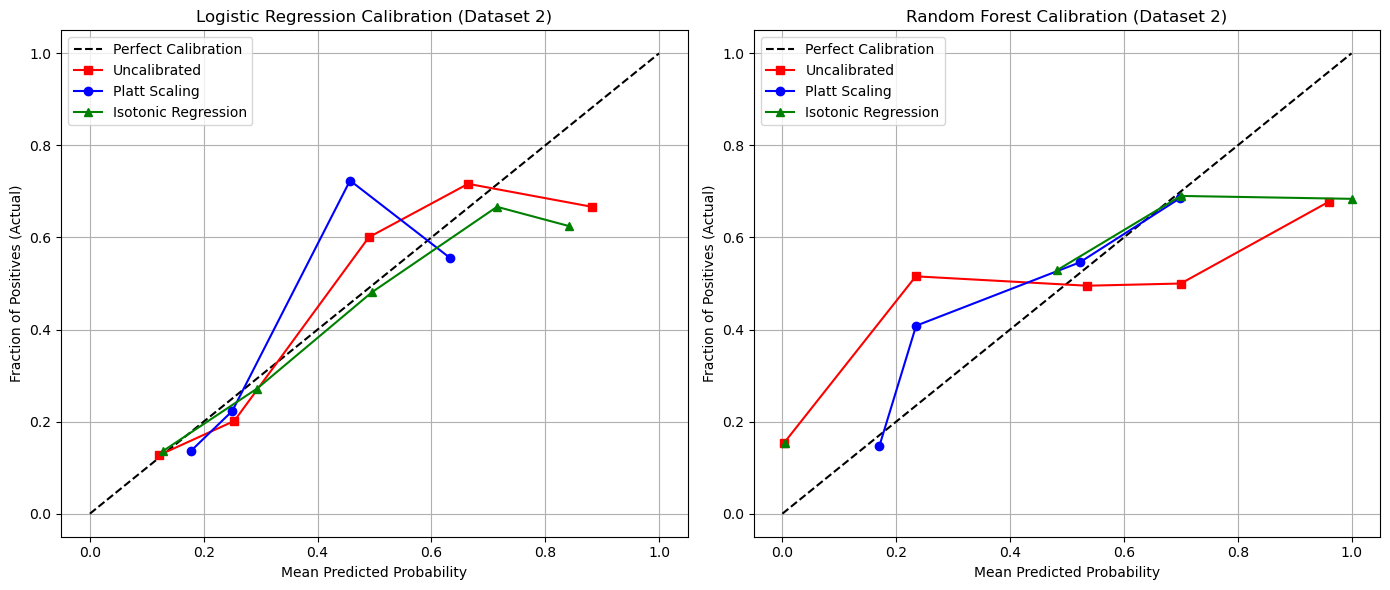

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

true_f, pred_p = manual_calibration_curve(y_test2, lr_probs_test2)
axes[0].plot(pred_p, true_f, "s-", color="red", label="Uncalibrated")

true_f_platt, pred_p_platt = manual_calibration_curve(y_test2, lr_probs_test_platt2)
axes[0].plot(pred_p_platt, true_f_platt, "o-", color="blue", label="Platt Scaling")

true_f_iso, pred_p_iso = manual_calibration_curve(y_test2, lr_probs_test_iso2)
axes[0].plot(pred_p_iso, true_f_iso, "^-", color="green", label="Isotonic Regression")

axes[0].set_title("Logistic Regression Calibration (Dataset 2)")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives (Actual)")
axes[0].legend()
axes[0].grid(True)


axes[1].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

true_f_rf, pred_p_rf = manual_calibration_curve(y_test2, rf_probs_test2)
axes[1].plot(pred_p_rf, true_f_rf, "s-", color="red", label="Uncalibrated")

true_f_rf_platt, pred_p_rf_platt = manual_calibration_curve(y_test2, rf_probs_test_platt2)
axes[1].plot(pred_p_rf_platt, true_f_rf_platt, "o-", color="blue", label="Platt Scaling")

true_f_rf_iso, pred_p_rf_iso = manual_calibration_curve(y_test2, rf_probs_test_iso2)
axes[1].plot(pred_p_rf_iso, true_f_rf_iso, "^-", color="green", label="Isotonic Regression")

axes[1].set_title("Random Forest Calibration (Dataset 2)")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives (Actual)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('calibration_curves_dataset2.png', dpi=300, bbox_inches='tight')
plt.show()